In [21]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
from mistralai.models import SDKError

In [2]:
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path)
from pipeline import Pipeline
from generator.question_answering import QA_Generator

## preprocess_corpus for one paragraph under different input parameters

In [3]:
# Define path for sample paragraph
sample_paragraph_dir = "..\\storage\\sample_paragraph"

In [6]:
# Define parameters for different preprocess methods
chunking_strategies = ['sentence', 'sentence','fixed-length','fixed-length','fixed-length']
fixed_length = [None,None,50,100,150]
overlap_size = [2,4,3,2,1]
# chunking_strategies = ['fixed-length']
# fixed_length = [50]
# overlap_size = [4]

In [ ]:
# Placeholder for vector counts from each configuration
vector_numbers = []
for c, f, o in zip(chunking_strategies, fixed_length, overlap_size):
    # Initialize pipeline
    pipeline = Pipeline(index_type='brute_force')
    pipeline.preprocess_corpus(sample_paragraph_dir, chunking_strategy=c, fixed_length=f, overlap_size=o)
    _,_,_,vector_number = pipeline.index_reporting()
    print("\n")
    vector_numbers.append(vector_number)

metadata: ['Young Adams went to Harvard College at age sixteen (in 1751). MSN Encarta, John Adams His father expected him to become a minister, but Adams had doubts.', 'After graduating in 1755, he taught school for a few years in Worcester, allowing himself time to think about his career choice. After much reflection, he decided to become a lawyer, and studied law in the office of James Putnam, a prominent lawyer in Worcester.', 'In 1758, he was admitted to the bar. From an early age, he developed the habit of writing descriptions of events and impressions of men.', 'These litter his diary. He put the skill to good use as a lawyer, often recording cases he observed so that he could study and reflect upon them.', 'His report of the 1761 argument of James Otis in the superior court of Massachusetts as to the legality of Writs of Assistance is a good example. Otis’s argument inspired Adams with zeal for the cause of the American colonies.', 'Ferling (1992) ch 2']

chunking_strategy: sent

([0, 1, 2, 3, 4],
 [Text(0, 0, 'sentence\nLength=None\nOverlap=2'),
  Text(1, 0, 'sentence\nLength=None\nOverlap=4'),
  Text(2, 0, 'fixed-length\nLength=50\nOverlap=3'),
  Text(3, 0, 'fixed-length\nLength=100\nOverlap=2'),
  Text(4, 0, 'fixed-length\nLength=150\nOverlap=1')])

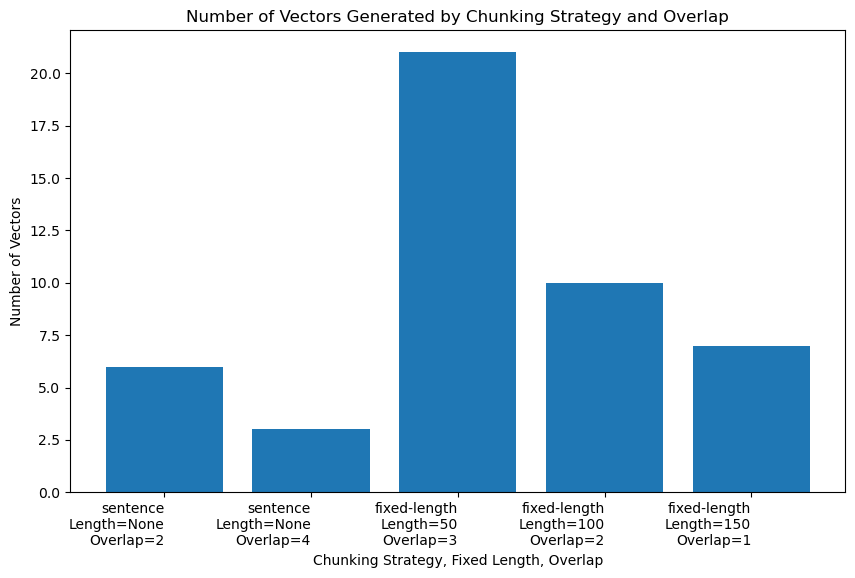

In [13]:
# Visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(
    [f"{c}\nLength={str(f)}\nOverlap={o}" for c, f, o in zip(chunking_strategies, fixed_length, overlap_size)],
    vector_numbers
)
plt.xlabel("Chunking Strategy, Fixed Length, Overlap")
plt.ylabel("Number of Vectors")
plt.title("Number of Vectors Generated by Chunking Strategy and Overlap")
plt.xticks(rotation=0, ha="right")

## Analysis on different re-ranking strategies

In [ ]:
# Define path for sample test
sample_corpus_path = "..\\storage\\sample_corpus" # Only contain S08_set3_a4.txt
sample_faiss_path = "..\\storage\\index\\faiss_index_sample.bin"
sample_metadata_path = "..\\storage\\index\\metadata_sample.pkl"

In [ ]:
# Initiate pipeline on S08_set3_a4.txt
pipeline_txt4 = Pipeline(index_type='brute_force')

In [5]:
# Preprocess the document and save the index
pipeline_txt4.preprocess_corpus(sample_corpus_path, chunking_strategy='sentence', fixed_length=None, overlap_size=2)
pipeline_txt4.indexer.save(sample_faiss_path, sample_metadata_path)

In [6]:
# Load the precomputed index
pipeline_txt4.indexer.load(sample_faiss_path, sample_metadata_path)

In [6]:
# Perform search and rerank and under different reranking strategies
query = "When did the Gettysburg address argue that America was born?"
reranking_results = {
    'cross_encoder':{
        'ranked_documents':[],
        'ranked_indices':[],
        'scores':[],
    },
    'tfidf':{
        'ranked_documents':[],
        'ranked_indices':[],
        'scores':[],
    },
    'hybrid':{
        'ranked_documents':[],
        'ranked_indices':[],
        'scores':[],
    },
    'sequential':{
        'ranked_documents':[],
        'ranked_indices':[],
        'scores':[],
    },
    'tfidf_corpus':{
        'ranked_documents':[],
        'ranked_indices':[],
        'scores':[],
    },    
}

### 1. Cross-encoder-only strategy

In [7]:
# Display and store data under the current reranking strategy
ranked_documents, ranked_indices, scores = pipeline_txt4.search_rerank(query, k=5, type="cross_encoder")

reranking_results['cross_encoder']['ranked_documents'].append(ranked_documents)
reranking_results['cross_encoder']['ranked_indices'].append(ranked_indices)
reranking_results['cross_encoder']['scores'].append(scores)

QUERY: When did the Gettysburg address argue that America was born?

NEAREST NEIGHBORS RESULTS:
Neighbor 1: Index 158, Distance 0.8181768655776978, Documents: Lincoln's second inauguration on March 4, 1865. In the photo, Lincoln's assassin, John Wilkes Booth, can be seen in the crowd at the top and accomplices David Herold, Lewis Powell, George Atzerodt, John Surratt and Edmund Spangler in the bottom crowd In his Gettysburg Address Lincoln redefined the American nation, arguing that it was born not in 1789 but in 1776, "conceived in Liberty, and dedicated to the proposition that all men are created equal."
Neighbor 2: Index 151, Distance 0.8774310350418091, Documents: His extraordinary command of the English language was evidenced in the Gettysburg Address, a speech dedicating the cemetery at Gettysburg that he delivered on November 19, 1863. The speech defied Lincoln's own prediction that "the world will little note, nor long remember what we say here."
Neighbor 3: Index 87, Distance 

### 2. TF-IDF-only strategy

In [8]:
# Display and store data under the current reranking strategy
ranked_documents, ranked_indices, scores = pipeline_txt4.search_rerank(query, k=5, type="tfidf")

reranking_results['tfidf']['ranked_documents'].append(ranked_documents)
reranking_results['tfidf']['ranked_indices'].append(ranked_indices)
reranking_results['tfidf']['scores'].append(scores)

QUERY: When did the Gettysburg address argue that America was born?

NEAREST NEIGHBORS RESULTS:
Neighbor 1: Index 158, Distance 0.8181768655776978, Documents: Lincoln's second inauguration on March 4, 1865. In the photo, Lincoln's assassin, John Wilkes Booth, can be seen in the crowd at the top and accomplices David Herold, Lewis Powell, George Atzerodt, John Surratt and Edmund Spangler in the bottom crowd In his Gettysburg Address Lincoln redefined the American nation, arguing that it was born not in 1789 but in 1776, "conceived in Liberty, and dedicated to the proposition that all men are created equal."
Neighbor 2: Index 151, Distance 0.8774310350418091, Documents: His extraordinary command of the English language was evidenced in the Gettysburg Address, a speech dedicating the cemetery at Gettysburg that he delivered on November 19, 1863. The speech defied Lincoln's own prediction that "the world will little note, nor long remember what we say here."
Neighbor 3: Index 87, Distance 

### 3. Cross-encoder and TF-IDF hybrid strategy

In [9]:
# Display and store data under the current reranking strategy
ranked_documents, ranked_indices, scores = pipeline_txt4.search_rerank(query, k=5, type="hybrid")

reranking_results['hybrid']['ranked_documents'].append(ranked_documents)
reranking_results['hybrid']['ranked_indices'].append(ranked_indices)
reranking_results['hybrid']['scores'].append(scores)

QUERY: When did the Gettysburg address argue that America was born?

NEAREST NEIGHBORS RESULTS:
Neighbor 1: Index 158, Distance 0.8181768655776978, Documents: Lincoln's second inauguration on March 4, 1865. In the photo, Lincoln's assassin, John Wilkes Booth, can be seen in the crowd at the top and accomplices David Herold, Lewis Powell, George Atzerodt, John Surratt and Edmund Spangler in the bottom crowd In his Gettysburg Address Lincoln redefined the American nation, arguing that it was born not in 1789 but in 1776, "conceived in Liberty, and dedicated to the proposition that all men are created equal."
Neighbor 2: Index 151, Distance 0.8774310350418091, Documents: His extraordinary command of the English language was evidenced in the Gettysburg Address, a speech dedicating the cemetery at Gettysburg that he delivered on November 19, 1863. The speech defied Lincoln's own prediction that "the world will little note, nor long remember what we say here."
Neighbor 3: Index 87, Distance 

### 4. TF-IDF, then cross-encoder strategy

In [10]:
# Display and store data under the current reranking strategy
ranked_documents, ranked_indices, scores = pipeline_txt4.search_rerank(query, k=5, type="sequential")

reranking_results['sequential']['ranked_documents'].append(ranked_documents)
reranking_results['sequential']['ranked_indices'].append(ranked_indices)
reranking_results['sequential']['scores'].append(scores)

QUERY: When did the Gettysburg address argue that America was born?

NEAREST NEIGHBORS RESULTS:
Neighbor 1: Index 158, Distance 0.8181768655776978, Documents: Lincoln's second inauguration on March 4, 1865. In the photo, Lincoln's assassin, John Wilkes Booth, can be seen in the crowd at the top and accomplices David Herold, Lewis Powell, George Atzerodt, John Surratt and Edmund Spangler in the bottom crowd In his Gettysburg Address Lincoln redefined the American nation, arguing that it was born not in 1789 but in 1776, "conceived in Liberty, and dedicated to the proposition that all men are created equal."
Neighbor 2: Index 151, Distance 0.8774310350418091, Documents: His extraordinary command of the English language was evidenced in the Gettysburg Address, a speech dedicating the cemetery at Gettysburg that he delivered on November 19, 1863. The speech defied Lincoln's own prediction that "the world will little note, nor long remember what we say here."
Neighbor 3: Index 87, Distance 

### 5. TF-IDF-only on the full chunked corpus strategy

In [11]:
# Display and store data under the current reranking strategy
ranked_documents, ranked_indices, scores = pipeline_txt4.search_rerank(query, k=5, type="tfidf_corpus")

reranking_results['tfidf_corpus']['ranked_documents'].append(ranked_documents)
reranking_results['tfidf_corpus']['ranked_indices'].append(ranked_indices)
reranking_results['tfidf_corpus']['scores'].append(scores)

QUERY: When did the Gettysburg address argue that America was born?

NEAREST NEIGHBORS RESULTS:
Neighbor 1: Index 158, Distance 0.8181768655776978, Documents: Lincoln's second inauguration on March 4, 1865. In the photo, Lincoln's assassin, John Wilkes Booth, can be seen in the crowd at the top and accomplices David Herold, Lewis Powell, George Atzerodt, John Surratt and Edmund Spangler in the bottom crowd In his Gettysburg Address Lincoln redefined the American nation, arguing that it was born not in 1789 but in 1776, "conceived in Liberty, and dedicated to the proposition that all men are created equal."
Neighbor 2: Index 151, Distance 0.8774310350418091, Documents: His extraordinary command of the English language was evidenced in the Gettysburg Address, a speech dedicating the cemetery at Gettysburg that he delivered on November 19, 1863. The speech defied Lincoln's own prediction that "the world will little note, nor long remember what we say here."
Neighbor 3: Index 87, Distance 

### Ranking strategies analysis

For the query: "When did the Gettysburg address argue that America was born?"

1. **Cross-Encoder**

- **Performance**: The cross-encoder ranks the most relevant document about the Gettysburg Address and America’s founding at the top with a very high score (4.818).
- **Observation**: The cross-encoder’s scores vary significantly between relevant and non-relevant documents, as seen with high-ranking documents scoring positive values while less relevant documents have negative scores.
- **Impact**: Cross-encoder re-ranking is highly effective for relevance but can be computationally expensive, particularly with large corpora due to the need for pairwise scoring. This makes it suitable for final-stage re-ranking after initial filtering with faster methods.

2. **TF-IDF**

- **Performance**: TF-IDF ranks relevant documents about the Gettysburg Address and America’s founding but shows some limitations in ranking precision. Some relevant documents are ranked lower than in the cross-encoder results.
- **Observation**: Scores are positive and closely spaced, indicating that TF-IDF does not distinguish as strongly between highly relevant and less relevant documents.
- **Impact**: TF-IDF is efficient for initial filtering of a large corpus, where it can quickly narrow down to a manageable set of documents. However, due to less nuanced scoring, it is most effective when combined with a secondary re-ranking method, such as a cross-encoder, to refine the top results.

3. **Hybrid (TF-IDF + Cross-Encoder)**

- **Performance**: The hybrid method effectively combines TF-IDF for initial selection and cross-encoder for fine-grained ranking, placing highly relevant documents about the Gettysburg Address and America’s founding at the top.
- **Observation**: The hybrid scores show a moderate spread, with top documents scoring positively and lower-ranked documents moving to negative scores. This balanced approach helps filter noise while maintaining precision in top results.
- **Impact**: The hybrid approach balances efficiency and relevance. TF-IDF filters the corpus quickly, and the cross-encoder re-ranks the top results, making it highly suitable for systems that need both speed and relevance. It reduces computational load by limiting cross-encoder scoring to fewer documents.

4. **Sequential (TF-IDF followed by Cross-Encoder)**

- **Performance**: Similar to the hybrid approach, sequential re-ranking efficiently combines TF-IDF and cross-encoder in two distinct stages. It ranks the relevant Gettysburg document highly and shows a clear score distinction between relevant and irrelevant content.
- **Observation**: This method’s scores align closely with hybrid re-ranking, effectively utilizing TF-IDF to select top candidates before cross-encoder scoring.
- **Impact**: Sequential re-ranking is efficient, adaptable, and modular, enabling easy substitution of the initial retrieval method (e.g., BM25 or TF-IDF). It reduces the need for exhaustive cross-encoder computations on the entire corpus, making it ideal for large-scale systems prioritizing response time without sacrificing accuracy.

5. **TF-IDF Corpus**
- **Performance**: TF-IDF corpus-based ranking selects relevant documents but struggles to identify the top-ranking document about the specific details of America’s founding in the Gettysburg Address.
- **Observation**: Scores are closely grouped and lack strong differentiation, indicating that while TF-IDF effectively brings in topic-related documents, it lacks precision for nuanced queries.
- **Impact**: TF-IDF corpus-based re-ranking is fast and scalable, suitable for early-stage filtering. However, its lack of precision in nuanced ranking suggests it would need to be followed by more discriminative methods like cross-encoder re-ranking for improved relevance.

## Model performance using QA_generator

In [3]:
# Define path for sample test
sample_corpus_path = "..\\storage\\corpus"
sample_faiss_path = "..\\storage\\index\\faiss_index_corpus.bin"
sample_metadata_path = "..\\storage\\index\\metadata_corpus.pkl"

In [ ]:
# Initiate pipeline on corpus
pipeline = Pipeline(index_type='brute_force')

In [10]:
# Preprocess the document and save the index
pipeline.preprocess_corpus(sample_corpus_path, chunking_strategy='sentence', fixed_length=None, overlap_size=2)
pipeline.indexer.save(sample_faiss_path, sample_metadata_path)

In [5]:
# Load the precomputed index
pipeline.indexer.load(sample_faiss_path, sample_metadata_path)

In [6]:
# Load generator model on Mistral AI
# SG API Key: HkmJtr1P6fYblPj0wbuveBz7SaKx7oW8
# set MISTRAL_API_KEY=HkmJtr1P6fYblPj0wbuveBz7SaKx7oW8
generator_model = "mistral-large-latest"
generator = QA_Generator(api_key = os.environ["MISTRAL_API_KEY"], temperature=0.2, generator_model=generator_model)

In [42]:
# Initialize the transformer model for transformer match metric
similarity_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
# Define a similarity threshold for a generated_answer to be defined as "correct"
similarity_threshold = 0.5


In [43]:
# Load the questions.csv file
question_path = "..\\qa_resources\\questions.csv"
df = pd.read_csv(question_path, delimiter='\t')

# Remove duplicates
# df = df.drop_duplicates(subset=['Question']).reset_index(drop=True)

In [44]:
# Define a dictionary to store reranking results
results = {strategy: [] for strategy in ["cross_encoder", "hybrid"]}

In [45]:
# Query under different strategies
for strategy in results.keys():
    # Loop over each question in questions.csv
    for index, row in df.iterrows():
        question = row['Question']
        true_answer = row['Answer']

        #1. Use the pipeline to search and rerank the top contexts for the query
        contexts,_,_ = pipeline.search_rerank(question, k=5, type=strategy, reporting=False)

        #2. Use QA_generator to generate an answer
        try:
            generated_answer = generator.generate_answer(question, contexts)
        except SDKError as e:
            if e.status_code == 429:  # Rate limit error
                print("Rate limit exceeded. Waiting for 5 seconds before retrying...")
                time.sleep(5)  # Wait before retrying
                generated_answer = generator.generate_answer(question, contexts)
        
        #3. Calculate similarity between true and generated answer
        true_answer = str(true_answer)
        generated_answer = str(generated_answer)
        
        embeddings = similarity_model.encode([generated_answer, true_answer], convert_to_tensor=True)
        similarity_score = util.pytorch_cos_sim(embeddings[0], embeddings[1]).item()

        is_correct = True if similarity_score >= similarity_threshold else False

        #4. Store results
        results[strategy].append((is_correct, similarity_score, generated_answer, true_answer))

    print(f"Searched for all questions under reranking strategy: {strategy}.")



[ChatCompletionChoice(index=0, message=AssistantMessage(content='Yes, Abraham Lincoln was the sixteenth President of the United States.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]
[ChatCompletionChoice(index=0, message=AssistantMessage(content='Yes, Abraham Lincoln was the sixteenth President of the United States.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]
[ChatCompletionChoice(index=0, message=AssistantMessage(content='Yes, Lincoln signed the National Banking Act of 1863.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]
[ChatCompletionChoice(index=0, message=AssistantMessage(content='Yes, Lincoln signed the National Banking Act of 1863.', tool_calls=None, prefix=False, role='assistant'), finish_reason='stop')]
[ChatCompletionChoice(index=0, message=AssistantMessage(content="No context. The context provided does not mention that his mother died of pneumonia. It states that Theodore Roosevelt's moth

In [46]:
print(results['cross_encoder'][0])

(False, 0.15754173696041107, 'Yes, Abraham Lincoln was the sixteenth President of the United States.', 'yes')


In [48]:
# Calculate evaluation metrics for each strategy
metrics = {}
for strategy, outcomes in results.items():
    # Extract correct/incorrect results
    y_true = [result[0] for result in outcomes] 
    
    # Calculate accuracy, precision, recall, and F1 score
    accuracy = accuracy_score(y_true, [True] * len(y_true))  # All True as we measure accuracy of correct answers
    precision = precision_score(y_true, [True] * len(y_true), zero_division=1)
    recall = recall_score(y_true, [True] * len(y_true), zero_division=1)
    f1 = f1_score(y_true, [True] * len(y_true), zero_division=1)
    
    # Store the metrics for each strategy
    metrics[strategy] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

# Print or analyze the metrics for each re-ranking strategy
print("Performance Metrics by Re-Ranking Strategy:")
for strategy, scores in metrics.items():
    print(f"\n{strategy.capitalize()} Strategy:")
    for metric, score in scores.items():
        print(f"  {metric.capitalize()}: {score:.4f}")

Performance Metrics by Re-Ranking Strategy:

Cross_encoder Strategy:
  Accuracy: 0.2569
  Precision: 0.2569
  Recall: 1.0000
  F1_score: 0.4088

Hybrid Strategy:
  Accuracy: 0.2661
  Precision: 0.2661
  Recall: 1.0000
  F1_score: 0.4203


The hybrid approach marginally improves performance by combining the strengths of TF-IDF filtering and cross-encoder refinement. However, the improvement is slight, indicating room for improvement in precision by further fine tuning the model.